# Exercise 9.4 — Bifurcation Diagram and Lyapunov Exponent of a Cosine-Squared Map

## Problem

Plot the bifurcation diagram and the Lyapunov exponent of the following discrete-time dynamical system for $r > 0$:

$$x_t = \cos^2(r x_{t-1}) \qquad (9.8)$$

Then explain how its dynamics change over $r$.

## Setup

Define the map $f(x) = \cos^2(rx)$. Since $\cos^2(\cdot) \in [0,1]$ for any input, the state space $[0,1]$ is invariant — after the first iteration, $x_t$ stays in $[0,1]$ for all time.

**Derivative (needed for the Lyapunov exponent):**

$$f'(x) = 2\cos(rx) \cdot (-\sin(rx)) \cdot r = -r\sin(2rx)$$

**Lyapunov exponent:**

$$\lambda = \lim_{n \to \infty} \frac{1}{n} \sum_{i=0}^{n-1} \ln|f'(x_i)| = \lim_{n\to\infty} \frac{1}{n}\sum_{i=0}^{n-1} \ln\bigl(r|\sin(2rx_i)|\bigr)$$

- $\lambda < 0$: nearby orbits converge — ordered behavior (fixed point or periodic orbit)
- $\lambda = 0$: marginal stability — bifurcation boundary
- $\lambda > 0$: nearby orbits diverge — chaotic behavior

In [1]:
import numpy as np
import matplotlib.pyplot as plt

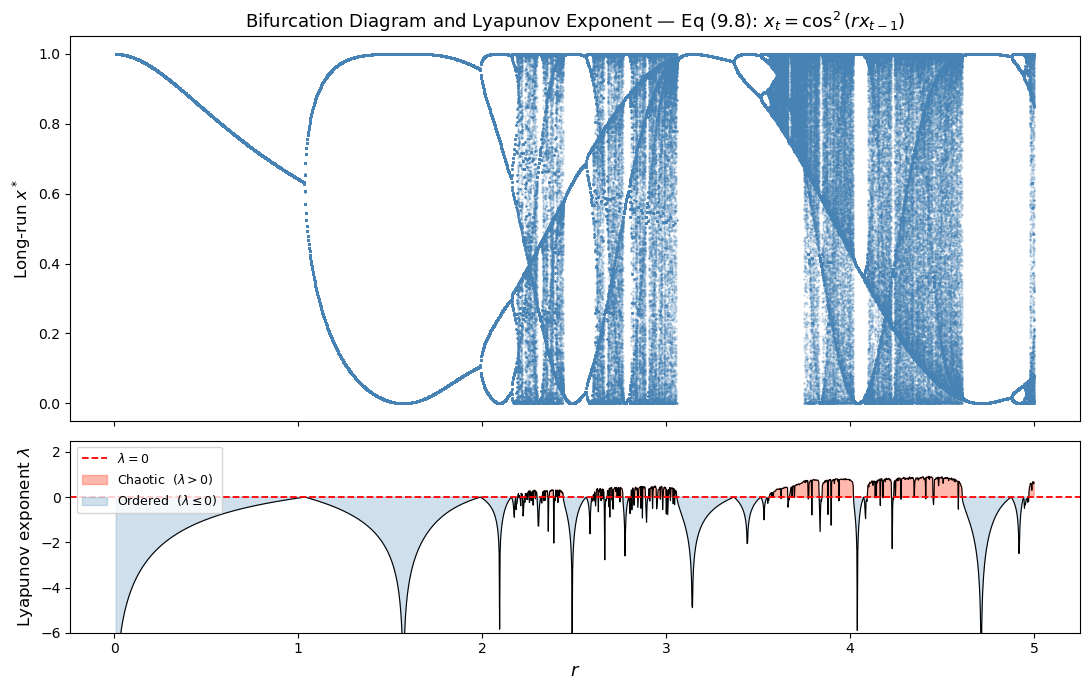

In [2]:
# Map and its derivative
def f_map(x, r):
    return np.cos(r * x)**2

def f_deriv(x, r):
    return -r * np.sin(2 * r * x)

r_vals   = np.linspace(0.01, 5.0, 2000)
n_trans  = 1000   # transient iterates (discarded)
n_plot   = 300    # iterates collected for bifurcation diagram
n_lyap   = 8000   # iterates for Lyapunov average

# ── Bifurcation diagram ──────────────────────────────────────────────────────
x = np.full_like(r_vals, 0.5)
for _ in range(n_trans):
    x = f_map(x, r_vals)

bif_r, bif_x = [], []
for _ in range(n_plot):
    x = f_map(x, r_vals)
    bif_r.append(r_vals.copy())
    bif_x.append(x.copy())
bif_r = np.concatenate(bif_r)
bif_x = np.concatenate(bif_x)

# ── Lyapunov exponent ────────────────────────────────────────────────────────
x = np.full_like(r_vals, 0.5)
for _ in range(n_trans):
    x = f_map(x, r_vals)

lyap = np.zeros_like(r_vals)
for _ in range(n_lyap):
    d = np.abs(f_deriv(x, r_vals))
    lyap += np.log(np.maximum(d, 1e-14))   # floor avoids log(0)
    x = f_map(x, r_vals)
lyap /= n_lyap

# ── Combined figure ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(11, 7), sharex=True,
    gridspec_kw={'height_ratios': [2, 1]}
)

ax1.scatter(bif_r, bif_x, s=0.2, color='steelblue', alpha=0.35, rasterized=True)
ax1.set_ylabel('Long-run $x^*$', fontsize=12)
ax1.set_title(
    r'Bifurcation Diagram and Lyapunov Exponent — Eq (9.8): $x_t = \cos^2(rx_{t-1})$',
    fontsize=13
)
ax1.set_ylim(-0.05, 1.05)

ax2.plot(r_vals, lyap, 'k', lw=0.8)
ax2.axhline(0, color='r', ls='--', lw=1.3, label='$\\lambda = 0$')
ax2.fill_between(r_vals, lyap, 0,
                  where=(lyap > 0),  color='tomato',    alpha=0.45, label='Chaotic  ($\\lambda > 0$)')
ax2.fill_between(r_vals, lyap, 0,
                  where=(lyap <= 0), color='steelblue', alpha=0.25, label='Ordered  ($\\lambda \\leq 0$)')
ax2.set_ylabel('Lyapunov exponent $\\lambda$', fontsize=12)
ax2.set_xlabel('$r$', fontsize=13)
ax2.set_ylim(-6, 2.5)
ax2.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

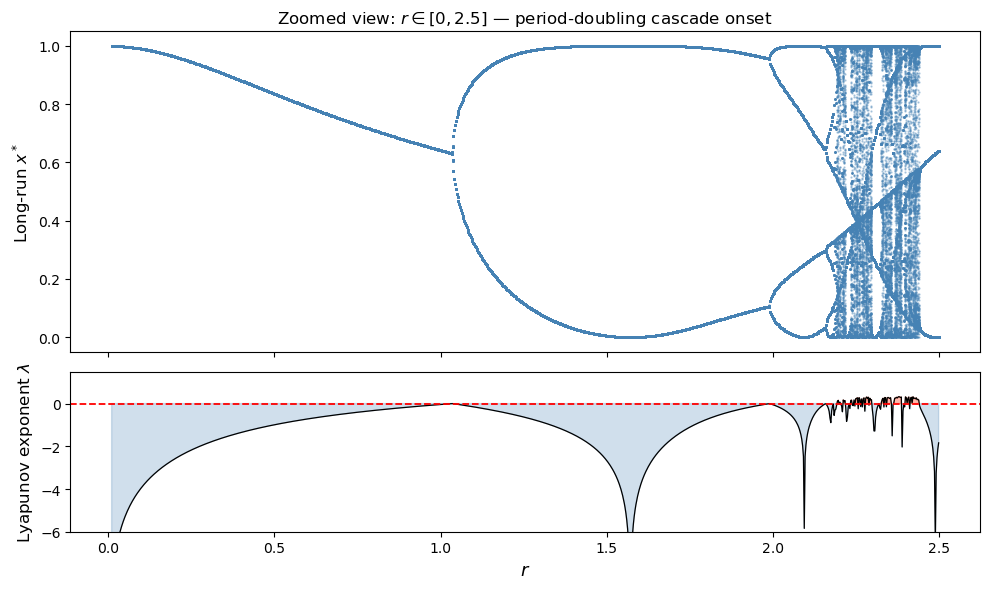

In [3]:
# ── Zoomed view: onset of the first period-doubling cascade ─────────────────
mask = (r_vals >= 0.01) & (r_vals <= 2.5)
r_zoom = r_vals[mask]
lyap_zoom = lyap[mask]
mask_bif  = (bif_r <= 2.5)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True,
    gridspec_kw={'height_ratios': [2, 1]}
)

ax1.scatter(bif_r[mask_bif], bif_x[mask_bif],
            s=0.4, color='steelblue', alpha=0.4, rasterized=True)
ax1.set_ylabel('Long-run $x^*$', fontsize=12)
ax1.set_title('Zoomed view: $r \\in [0, 2.5]$ — period-doubling cascade onset', fontsize=12)
ax1.set_ylim(-0.05, 1.05)

ax2.plot(r_zoom, lyap_zoom, 'k', lw=0.9)
ax2.axhline(0, color='r', ls='--', lw=1.3)
ax2.fill_between(r_zoom, lyap_zoom, 0,
                  where=(lyap_zoom > 0),  color='tomato',    alpha=0.45)
ax2.fill_between(r_zoom, lyap_zoom, 0,
                  where=(lyap_zoom <= 0), color='steelblue', alpha=0.25)
ax2.set_ylabel('Lyapunov exponent $\\lambda$', fontsize=12)
ax2.set_xlabel('$r$', fontsize=13)
ax2.set_ylim(-6, 1.5)

plt.tight_layout()
plt.show()

## Explanation: How the Dynamics Change over $r$

### Small $r$ — Stable fixed point

For small $r$, the map $f(x) = \cos^2(rx)$ is nearly flat, and every orbit converges rapidly to a single stable fixed point. The derivative $|f'(x^*)| = r|\sin(2rx^*)| \ll 1$, so the Lyapunov exponent is strongly negative. The system just locks in to one value and stays there.

### Period-doubling cascade

As $r$ increases, the map steepens. When $|f'(x^*)| = 1$, the fixed point loses stability and a period-2 orbit is born — the classic period-doubling bifurcation. Increasing $r$ further triggers another doubling to period-4, then period-8, and so on. This cascade follows the Feigenbaum route to chaos. In the Lyapunov plot, each bifurcation appears as a spike toward zero (the multiplier briefly passes through $\pm 1$), and the exponent stays negative throughout the cascade.

### Onset of chaos

After the period-doubling cascade accumulates, $\lambda$ crosses zero and becomes positive. This marks the onset of chaotic dynamics — trajectories starting at nearby initial conditions diverge exponentially. The bifurcation diagram fans out into a continuous band of visited $x$ values.

### Periodic windows within chaos

Inside the chaotic regime, narrow windows of periodicity are visible in the bifurcation diagram — short bands where the orbit collapses back to a finite cycle. These correspond to dips in $\lambda$ back below zero. This is exactly the same structure seen in the logistic map, and is a universal feature of one-dimensional unimodal maps.

### Second chaos-order-chaos cycle (larger $r$)

Because $\cos^2(rx)$ is periodic in $r$, the entire period-doubling cascade and chaos scenario **repeats** as $r$ increases further. After a chaotic band, the system can restabilize into ordered behavior, then period-double into chaos again. This gives the bifurcation diagram its layered, self-similar appearance at larger $r$ — a behavior that distinguishes the cosine-squared map from simpler maps like the logistic one.

### Summary table

| $r$ regime | Bifurcation diagram | $\lambda$ |
|:----------:|:-------------------:|:---------:|
| Small $r$ | Single point (fixed) | $\lambda \ll 0$ |
| Period-doubling cascade | Successive doublings | $\lambda < 0$, spikes to $0$ at each bifurcation |
| First chaotic band | Dense band | $\lambda > 0$ |
| Periodic windows | Narrow bands within chaos | $\lambda < 0$ (dips) |
| Larger $r$ | Repeated cascades + chaos | Alternating sign |